In [60]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

n_per_group = 40
group_centers = [-1, 0, 1]
sigma = 0.32

x_group_all = []
y_group_all = []
size_group_all = []

for i, center in enumerate(group_centers):
    x_group = np.random.normal(loc=center, scale=sigma, size=n_per_group)
    x_group_all.append(x_group)

    y_group = np.random.uniform(-0.05, 0.05, size=n_per_group)
    y_group_all.append(y_group)


    distances = np.abs(x_group - center)
    size_group = size_group = 200 * (1 - distances / distances.max())

    size_group_all.append(size_group)

x_group_all = np.array(x_group_all)
y_group_all = np.array(y_group_all)
size_group_all = np.array(size_group_all)

In [49]:
x_group_all.shape

(3, 40)

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'Comic Sans MS' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
fin

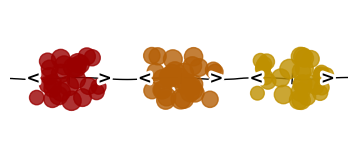

In [84]:


# Settings


group_labels = ['b', 't', '']
colors = ['#990000', '#b45f06', '#bf9000']

# Generate data
x_vals = []
y_vals = []
blob_sizes = []
blob_colors = []


for i, center in enumerate(group_centers):
    # Gaussian x around center
    
    pos = (np.abs(x_group_all[i] - center) <= sigma)
    x_group = x_group_all[i][pos]
    y_group = y_group_all[i][pos]

    size_group = size_group_all[i][pos]
    
    

    color_group = [colors[i]] * len(x_group)

    x_vals.extend(x_group)
    y_vals.extend(y_group)
    blob_sizes.extend(size_group)
    blob_colors.extend(color_group)

with plt.xkcd():
    # Plot
    fig, ax = plt.subplots(figsize=(3.8, 1.8))

    # Baseline line
    ax.axhline(0, color='black', linewidth=1, zorder=0)

    # Draw blobs
    ax.scatter(x_vals, y_vals, s=blob_sizes, c=blob_colors, alpha=0.8)

    # Ticks
    ax.set_xticks([])
    ax.set_xticklabels([])

    # Custom ticks at y=0
    for x, label in zip(group_centers, group_labels):
        ax.plot([x, x], [0.01, -0.01], color='black', lw=1, zorder=0)
        # ax.text(x, -0.05, label, ha='center', va='top', fontsize=10)


    # Style
    ax.get_yaxis().set_visible(False)
    for spine in ['left', 'right', 'top','bottom']:
        ax.spines[spine].set_visible(False)

    ax.set_xlim(-1.53, 1.5)
    ax.set_ylim(-0.15, 0.15)

    # Parameters
    sigma = 0.32  # Same as the Gaussian scale used for x_group
    offset = -0.02  # Vertical position for arrows

    for center in group_centers:
        # Left boundary
        ax.text(center - sigma, offset, '<', color='black', fontsize=12,
                ha='center', va='bottom', fontweight='bold')
        # Right boundary
        ax.text(center + sigma, offset, '>', color='black', fontsize=12,
                ha='center', va='bottom', fontweight='bold')


    plt.tight_layout()
    plt.savefig("stripplot.png", dpi=300, transparent=True,bbox_inches='tight', pad_inches=0)
    plt.show()


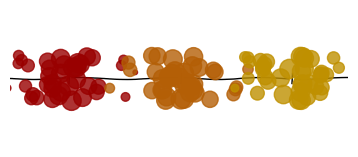

In [83]:
import matplotlib.patheffects as path_effects
custom_effect = [path_effects.withStroke(linewidth=1.5, foreground='#f2f1e9')]

# Settings


group_labels = ['b', 't', '']
colors = ['#990000', '#b45f06', '#bf9000']

# Generate data
x_vals = []
y_vals = []
blob_sizes = []
blob_colors = []


for i, center in enumerate(group_centers):
    # Gaussian x around center
    
    # pos = :
    x_group = x_group_all[i][:]
    y_group = y_group_all[i][:]

    
    size_group = size_group_all[i][:]

    color_group = [colors[i]] * len(x_group)

    x_vals.extend(x_group)
    y_vals.extend(y_group)
    blob_sizes.extend(size_group)
    blob_colors.extend(color_group)

with plt.xkcd():
    # Plot
    fig, ax = plt.subplots(figsize=(3.8, 1.8))

    # Baseline line
    ax.axhline(0, color='black', linewidth=1, zorder=0)

    # Draw blobs
    ax.scatter(x_vals, y_vals, s=blob_sizes, c=blob_colors, alpha=0.8)

    # Ticks
    ax.set_xticks([])
    ax.set_xticklabels([])

    # Custom ticks at y=0
    for x, label in zip(group_centers, group_labels):
        sc = ax.plot([x, x], [0.01, -0.01], color='black', lw=1, zorder=0)[0]
        # sc.set_path_effects(custom_effect)
        # ax.text(x, -0.05, label, ha='center', va='top', fontsize=10)


    # Style
    ax.get_yaxis().set_visible(False)
    for spine in ['left', 'right', 'top','bottom']:
        ax.spines[spine].set_visible(False)
        # ax.set_path_effects(custom_effect)

    ax.set_xlim(-1.53, 1.5)
    ax.set_ylim(-0.15, 0.15)

    plt.tight_layout()
    plt.savefig("stripplotW.png", dpi=300, transparent=True,bbox_inches='tight', pad_inches=0)
    plt.show()


In [67]:
from PIL import Image

# Open the saved image
img = Image.open("stripplotW.png").convert("RGBA")

# Replace white with transparent
datas = img.getdata()
newData = []
for item in datas:
    # If pixel is white (255,255,255), make it transparent
    if item[0:3] == (255, 255, 255):
        newData.append((255, 255, 255, 0))
    else:
        newData.append(item)

img.putdata(newData)
img.save("stripplot_cleanW.png", "PNG")


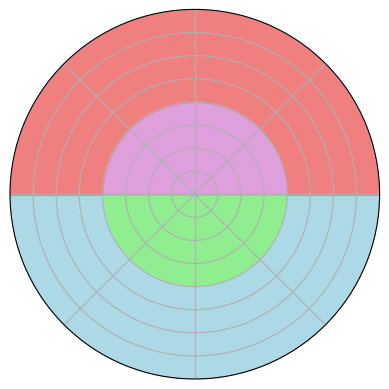

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# Turn off labels and grid
ax.set_yticklabels([])
ax.set_xticklabels([])
# ax.grid(False)

# Define radius values for circles
radii = [1, 2]
colors = ['lightgreen', 'plum', 'lightblue', 'lightcoral']

# Draw semicircles for each quadrant
theta = np.linspace(0, np.pi / 2, 100)

# [bt] regions (upper half)
ax.fill_between(theta, 0, 1, color=colors[0])  # green
ax.fill_between(theta + np.pi / 2, 0, 1, color=colors[0])

# [tb] regions (lower half)
ax.fill_between(theta + np.pi, 0, 1, color=colors[1])  # purple
ax.fill_between(theta + 3 * np.pi / 2, 0, 1, color=colors[1])

# [tt] outer upper quadrants
ax.fill_between(theta, 1, 2, color=colors[2])  # blue
ax.fill_between(theta + np.pi / 2, 1, 2, color=colors[2])

# [bb] outer lower quadrants
ax.fill_between(theta + np.pi, 1, 2, color=colors[3])  # red
ax.fill_between(theta + 3 * np.pi / 2, 1, 2, color=colors[3])

# Set limits
ax.set_rlim(0, 2)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)

# Set square aspect ratio
ax.set_aspect('equal', adjustable='box')

plt.show()


In [2]:
def plot_style():
    font_size       = 12
    dpi             = 200

    params = {'figure.dpi': dpi,
              'savefig.dpi': dpi,
              'font.size': font_size,
              'font.family': "serif",
              'figure.titlesize': font_size,
              'legend.fontsize': font_size,
              'axes.labelsize': font_size,
              'axes.titlesize': font_size,
              'xtick.labelsize': font_size,
              'ytick.labelsize': font_size,
              'text.usetex': True,
             }

    plt.rcParams.update(params)
plot_style()

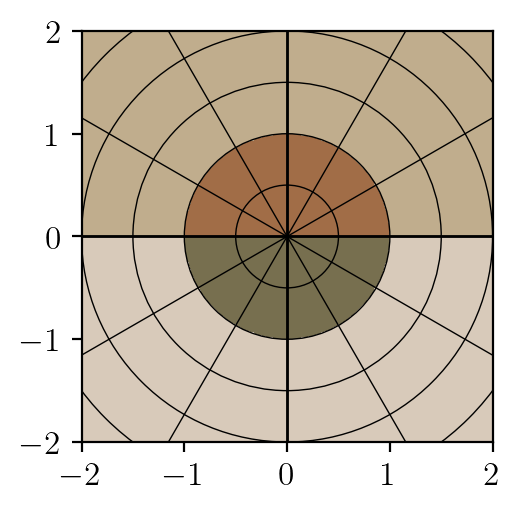

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axis
fig, ax = plt.subplots(figsize=(2.75, 2.75))

# Set the limits
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Create meshgrid
x = np.linspace(-3, 3, 500)
y = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

# Define Google Slides colors

colors = {
    "top_inner": "#A16D47",      # Muted clay (warm, earthy orange-brown)
    "bottom_inner": "#776F4F",      # Toasted almond (subtle tan/golden beige)
    "top_outer": "#C0AD8D",      # Sage green (natural, calming)
    "bottom_outer": "#D8CABA"       # Olive green (deep, grounding)
}

# Define regions by angle and radius with appropriate colors
regions = [
    ((R <= 1) & (Y >= 0), colors["top_inner"]),      # top inner
    ((R <= 1) & (Y < 0), colors["bottom_inner"]),     # bottom inner
    ((R > 1) & (R <= 3) & (Y >= 0), colors["top_outer"]),  # top outer
    ((R > 1) & (R <= 3) & (Y < 0), colors["bottom_outer"])       # bottom outer
]

# Plot each region
for mask, color in regions:
    ax.contourf(X, Y, mask, levels=[0.5, 1], colors=[color])

# Draw radial grid lines (black)
for angle in np.linspace(0, 2 * np.pi, 12, endpoint=False):
    ax.plot([0, 3 * np.cos(angle)], [0, 3 * np.sin(angle)], color='black', lw=0.5)

# Draw concentric circles (black)
for r in np.linspace(0.5, 3, 6):
    circle = plt.Circle((0, 0), r, color='black', fill=False, lw=0.5)
    ax.add_artist(circle)

# Draw x and y axes
ax.axhline(0, color='black', lw=1)
ax.axvline(0, color='black', lw=1)

# Set integer ticks
ticks = [-2, -1, 0, 1, 2]
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# Set equal aspect ratio
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig("circle.png", dpi=500, transparent=True,bbox_inches='tight', pad_inches=0)
    
plt.show()


In [17]:
np.logspace(-2, 0, 5)[:-1]

array([0.01      , 0.03162278, 0.1       , 0.31622777])